<a href="https://colab.research.google.com/github/ervatoker/IOT-Erva-Toker/blob/main/GANDALF_TONIoT_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CONFIG

DRIVE_DATASET = "/content/drive/MyDrive/datasets/toniot_arnob_dataset"
DRIVE_OUT_DIR = "/content/drive/MyDrive/toniot_outputs"

LABEL_COL   = "type"
RANDOM_SEED = 42
TEST_SIZE   = 0.2
VAL_SIZE    = 0.1

# Training settings
N_EPOCHS_TABM  = 256
EARLY_STOPPING = 20   # stop if no improvement for 20 epochs
BATCH_SIZE     = 512
DEVICE         = "cuda"

In [2]:
# INSTALL LIBRARIES
!pip install -q pytorch-tabular
!pip install -q scikit-learn pandas numpy matplotlib seaborn

print(" All packages installed restart runtime!")

 All packages installed restart runtime!


In [3]:
# IMPORTS + DRIVE + GPU CHECK

import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix,
                             precision_score, recall_score,
                             roc_auc_score, cohen_kappa_score,
                             matthews_corrcoef, roc_curve, auc)
from sklearn.preprocessing import label_binarize

from google.colab import drive
drive.mount("/content/drive")
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

# GPU check will crash if no GPU
if not torch.cuda.is_available():
    raise RuntimeError(
        "\n\n NO GPU DETECTED!\n"
        "→ Go to Runtime - Change runtime type\n"
        "→ Select T4 GPU\n"
        "→ Click Save\n"
        "→ Re-run from Cell 1\n"
    )

device = torch.device("cuda")
print(f" GPU confirmed : {torch.cuda.get_device_name(0)}")
print(f" VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f" Device        : {device}")

Mounted at /content/drive
 GPU confirmed : Tesla T4
 VRAM          : 15.6 GB
 Device        : cuda


In [4]:
# LOAD DATA

csv_files = glob.glob(os.path.join(DRIVE_DATASET, "**/*.csv"), recursive=True)
print(f"Found {len(csv_files)} CSV files")

dfs = []
for f in csv_files:
    try:
        dfs.append(pd.read_csv(f, low_memory=False))
    except Exception as e:
        print(f"  Skipped {f}: {e}")

df = pd.concat(dfs, ignore_index=True)
print(f"Total rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"\nLabel distribution:\n{df[LABEL_COL].value_counts()}")

Found 1 CSV files
Total rows: 211,043  |  Columns: 44

Label distribution:
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64


In [5]:
# PREPROCESS

# Drops label + non-feature columns
drop_cols = [LABEL_COL]
for col in ["ts", "src_ip", "dst_ip", "src_mac", "dst_mac"]:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(columns=drop_cols)
y_raw = df[LABEL_COL]

# Encodes string labels to integers
le = LabelEncoder()
y = le.fit_transform(y_raw)
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {list(le.classes_)}")

# Keeps numeric only + replace inf
X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan)
print(f"Features: {X.shape[1]}")

# Splits first
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED, stratify=y_tv)

print(f"\nTrain : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

# Imputes median on TRAIN only
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_val   = X_val.fillna(train_median)
X_test  = X_test.fillna(train_median)

# Scales on TRAIN only
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

n_features = X_train_s.shape[1]
print(f"\nFeatures after preprocessing : {n_features}")
print("Preprocessing complete — no data leakage")

Classes (10): ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
Features: 17

Train : 147,729
Val   : 21,105
Test  : 42,209

Features after preprocessing : 17
Preprocessing complete — no data leakage


In [6]:
# EVALUATION HELPER

def evaluate(model_name, y_true, y_pred, label_names, out_dir):
    acc      = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy     : {acc:.4f}")
    print(f"  F1 (macro)   : {f1_macro:.4f}")
    print(f"  F1 (weighted): {f1_weighted:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=label_names, zero_division=0)}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} — Confusion Matrix (TON-IoT)")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    save_path = os.path.join(out_dir, f"{model_name.lower().replace(' ','_')}_cm.png")
    plt.savefig(save_path, dpi=150); plt.show()
    print(f"Saved: {save_path}")

    return {"model": model_name, "accuracy": acc,
            "f1_macro": f1_macro, "f1_weighted": f1_weighted}

In [7]:
# TRAIN GANDALF

import pandas as pd
from pytorch_tabular import TabularModel
from pytorch_tabular.models import GANDALFConfig
from pytorch_tabular.config import (
    DataConfig, OptimizerConfig, TrainerConfig
)

print("Training GANDALF on TON-IoT...")

# Build DataFrames for pytorch-tabular
feature_cols = [f"f{i}" for i in range(n_features)]
target_col   = "target"

train_df = pd.DataFrame(X_train_s, columns=feature_cols)
train_df[target_col] = y_train.astype(str)

val_df = pd.DataFrame(X_val_s, columns=feature_cols)
val_df[target_col] = y_val.astype(str)

test_df = pd.DataFrame(X_test_s, columns=feature_cols)
test_df[target_col] = y_test.astype(str)

# Config
data_config = DataConfig(
    target=[target_col],
    continuous_cols=feature_cols,
    categorical_cols=[],
)

model_config = GANDALFConfig(
    task="classification",
    gflu_stages=6,
    gflu_dropout=0.0,
    learning_rate=1e-3,
)

trainer_config = TrainerConfig(
    auto_lr_find=False,
    batch_size=BATCH_SIZE,
    max_epochs=100,
    early_stopping="valid_loss",
    early_stopping_patience=EARLY_STOPPING,
    accelerator="gpu",
    devices=1,
    checkpoints_path=DRIVE_OUT_DIR,
)

optimizer_config = OptimizerConfig()

gandalf_model = TabularModel(
    data_config=data_config,
    model_config=model_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config,
)

gandalf_model.fit(
    train=train_df,
    validation=val_df,
)

print("GANDALF training complete")

2026-03-30 15:19:42,395 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
INFO:lightning_fabric.utilities.seed:Seed set to 42
2026-03-30 15:19:42,431 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders


Training GANDALF on TON-IoT...


2026-03-30 15:19:42,482 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for classification task
2026-03-30 15:19:42,631 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: GANDALFModel
2026-03-30 15:19:42,845 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-03-30 15:19:42,887 - {pytorch_tabular.tabular_model:677} - INFO - Training Started
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ GANDALFBackbone  │ 10.8 K │ train │     0 │
│ 1 │ _embedding_layer │ Embedding1dLayer │     34 │ train │     0 │
│ 2 │ _head            │ Sequential       │    190 │ train │     0 │
│ 3 │ loss             │ CrossEntropyLoss │      0 │ train │     0 │
└───┴──────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 11.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 27                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

2026-03-30 15:30:10,011 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-03-30 15:30:10,012 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model


GANDALF training complete


Probability matrix shape: (42209, 10)

  GANDALF
  Accuracy     : 0.8010
  F1 (macro)   : 0.6769
  F1 (weighted): 0.7775

              precision    recall  f1-score   support

    backdoor       0.96      0.99      0.97      4000
        ddos       0.84      0.33      0.47      4000
         dos       0.98      0.91      0.95      4000
   injection       0.55      0.92      0.69      4000
        mitm       0.33      0.04      0.07       209
      normal       1.00      1.00      1.00     10000
    password       0.70      0.11      0.19      4000
  ransomware       0.87      0.97      0.92      4000
    scanning       0.98      0.80      0.88      4000
         xss       0.47      0.92      0.62      4000

    accuracy                           0.80     42209
   macro avg       0.77      0.70      0.68     42209
weighted avg       0.84      0.80      0.78     42209



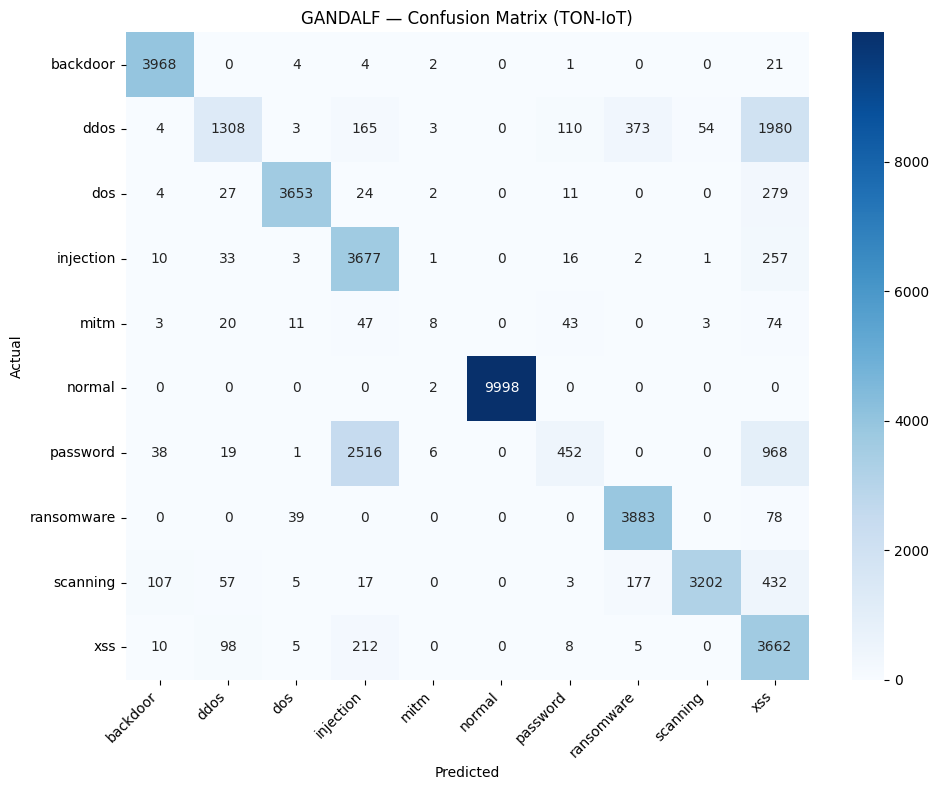

Saved: /content/drive/MyDrive/toniot_outputs/gandalf_cm.png

GANDALF | Train Acc: 0.8005 | Train F1: 0.6761
GANDALF | Test  Acc: 0.8010 | Test  F1: 0.6769
Gap: -0.0005


In [8]:
# EVALUATE GANDALF

# Test predictions
gandalf_test_pred_df  = gandalf_model.predict(test_df)

# Extract predicted class labels
gandalf_preds = gandalf_test_pred_df[[col for col in gandalf_test_pred_df.columns if 'target_' in col and '_probability' in col]].idxmax(axis=1).apply(lambda x: int(x.split('_')[1])).values

# Extract probability scores for ROC-AUC
prob_cols = sorted([col for col in gandalf_test_pred_df.columns if 'target_' in col and '_probability' in col],
                   key=lambda x: int(x.split('_')[1]))
gandalf_proba = gandalf_test_pred_df[prob_cols].values
print(f"Probability matrix shape: {gandalf_proba.shape}")

gandalf_results = evaluate(
    "GANDALF", y_test, gandalf_preds,
    label_names=list(le.classes_),
    out_dir=DRIVE_OUT_DIR
)

# Train metrics for overfitting check
gandalf_train_pred_df = gandalf_model.predict(train_df)
gandalf_train_preds   = gandalf_train_pred_df[[col for col in gandalf_train_pred_df.columns if 'target_' in col and '_probability' in col]].idxmax(axis=1).apply(lambda x: int(x.split('_')[1])).values
gandalf_train_acc     = accuracy_score(y_train, gandalf_train_preds)
gandalf_train_f1      = f1_score(y_train, gandalf_train_preds, average="macro", zero_division=0)
print(f"\nGANDALF | Train Acc: {gandalf_train_acc:.4f} | Train F1: {gandalf_train_f1:.4f}")
print(f"GANDALF | Test  Acc: {gandalf_results['accuracy']:.4f} | Test  F1: {gandalf_results['f1_macro']:.4f}")
print(f"Gap: {gandalf_train_acc - gandalf_results['accuracy']:.4f}")

  TABLE 1: GANDALF — Overall Evaluation Metrics
           Metric  Score
         Accuracy 0.8010
Precision (macro) 0.7692
   Recall (macro) 0.6989
       F1 (macro) 0.6769
    F1 (weighted) 0.7775
              MCC 0.7817
    Cohen's Kappa 0.7717
  ROC-AUC (macro) 0.9721



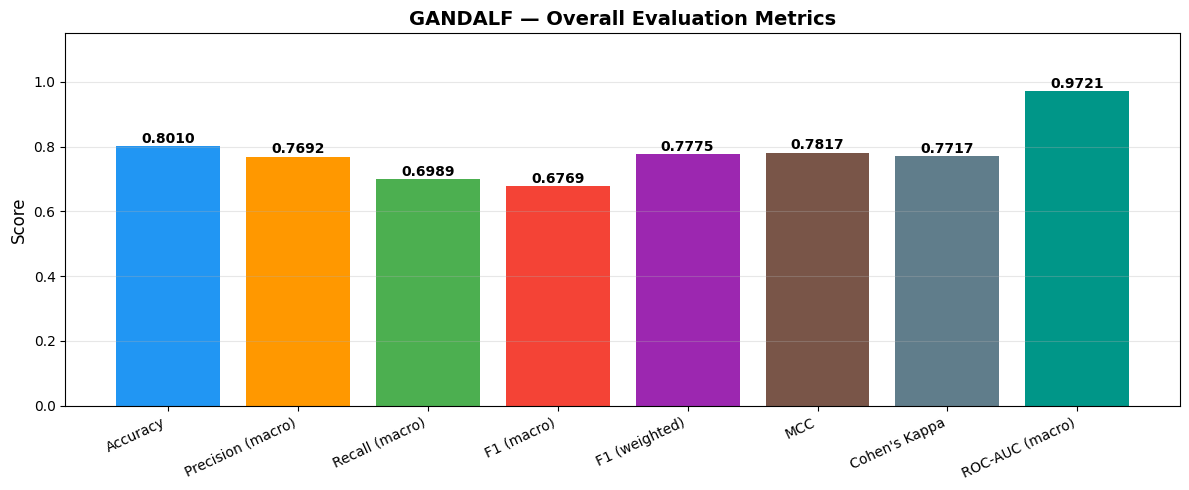

  TABLE 2: GANDALF — Per-Class Precision / Recall / F1
     Class  Precision  Recall  F1-Score  Support
  backdoor     0.9575  0.9920    0.9745     4000
      ddos     0.8374  0.3270    0.4703     4000
       dos     0.9809  0.9132    0.9459     4000
 injection     0.5519  0.9192    0.6897     4000
      mitm     0.3333  0.0383    0.0687      209
    normal     1.0000  0.9998    0.9999    10000
  password     0.7019  0.1130    0.1947     4000
ransomware     0.8745  0.9708    0.9201     4000
  scanning     0.9822  0.8005    0.8821     4000
       xss     0.4725  0.9155    0.6233     4000



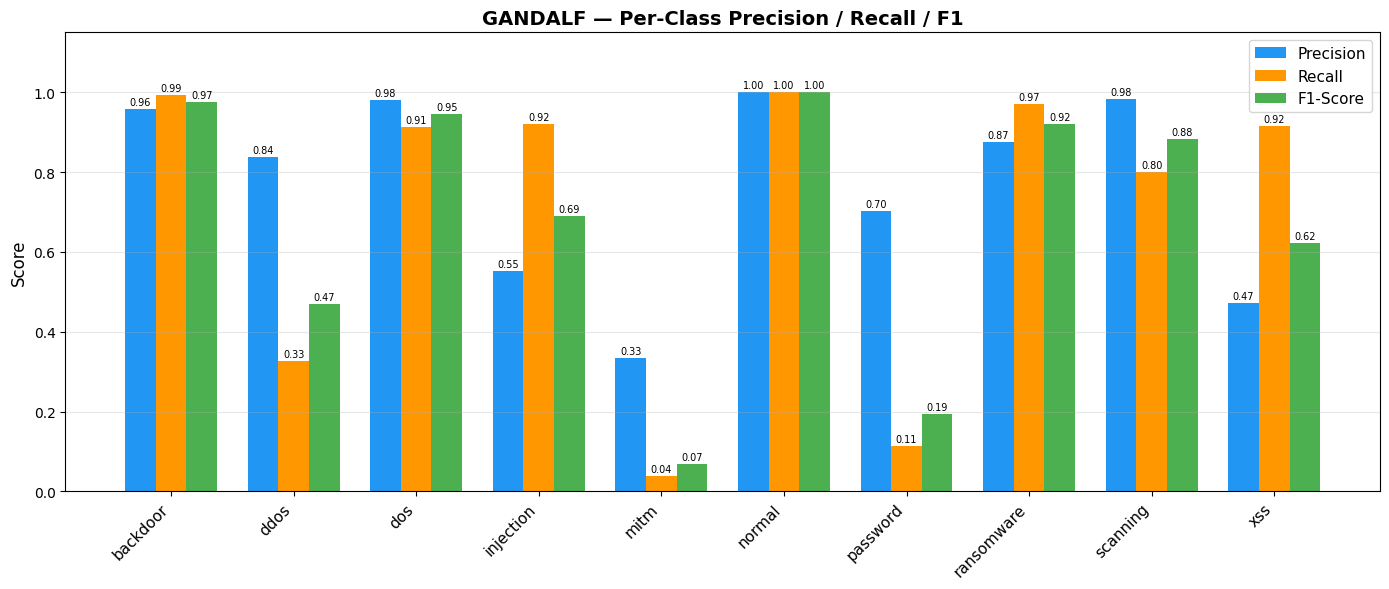

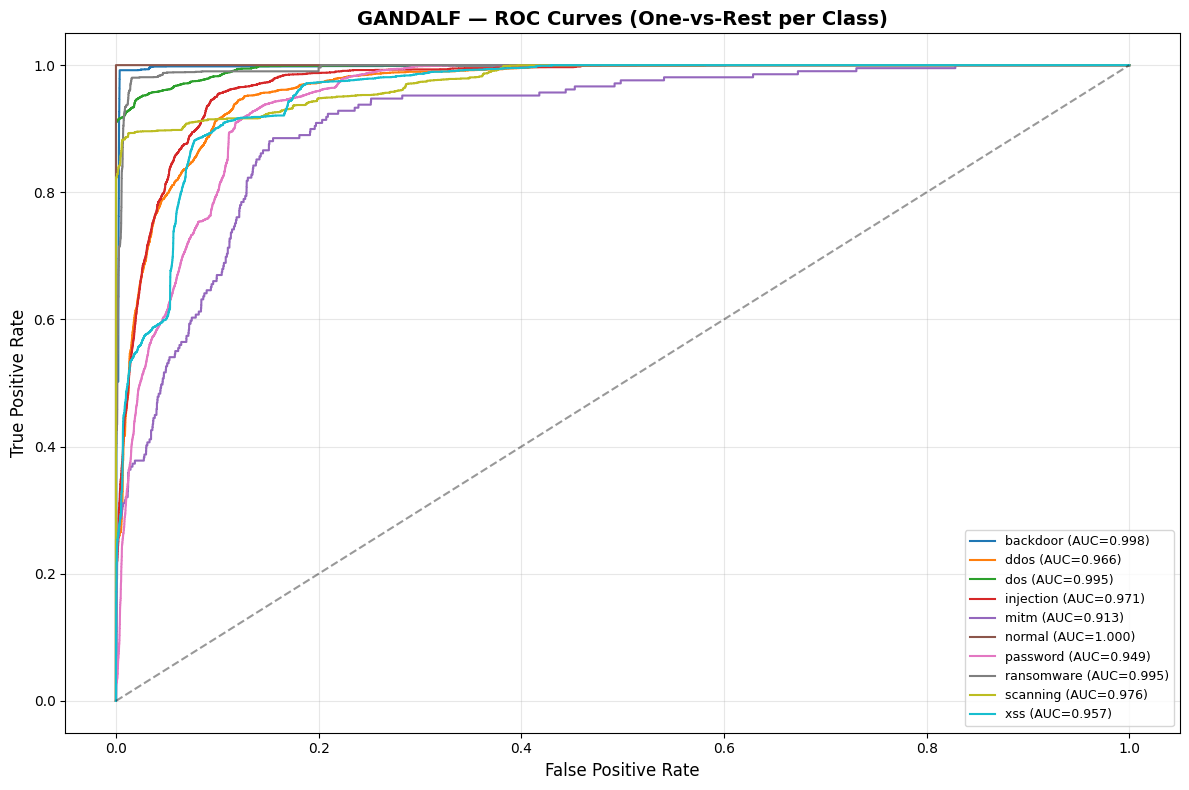

  TABLE 3: GANDALF — Per-Class ROC-AUC
     Class  ROC-AUC
  backdoor   0.9975
      ddos   0.9657
       dos   0.9952
 injection   0.9713
      mitm   0.9133
    normal   1.0000
  password   0.9490
ransomware   0.9951
  scanning   0.9763
       xss   0.9575

  Macro-average ROC-AUC: 0.9721

  TABLE 4: GANDALF — MCC & Cohen's Kappa
  MCC          : 0.7817 (Strong)
  Cohen's Kappa: 0.7717 (Substantial)


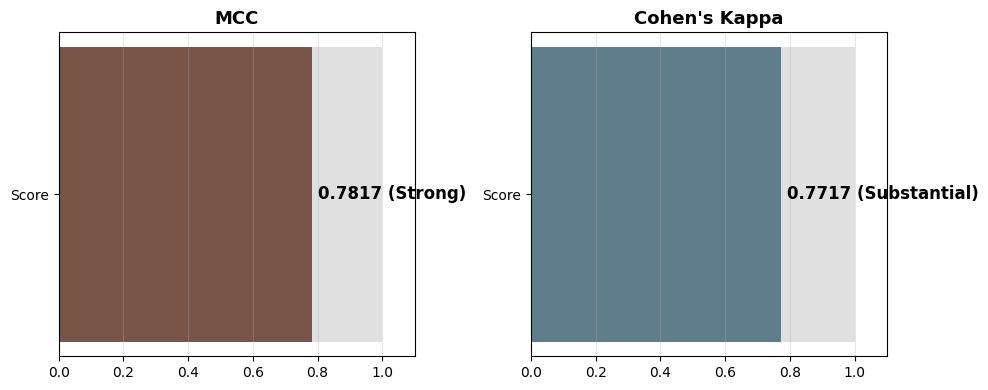

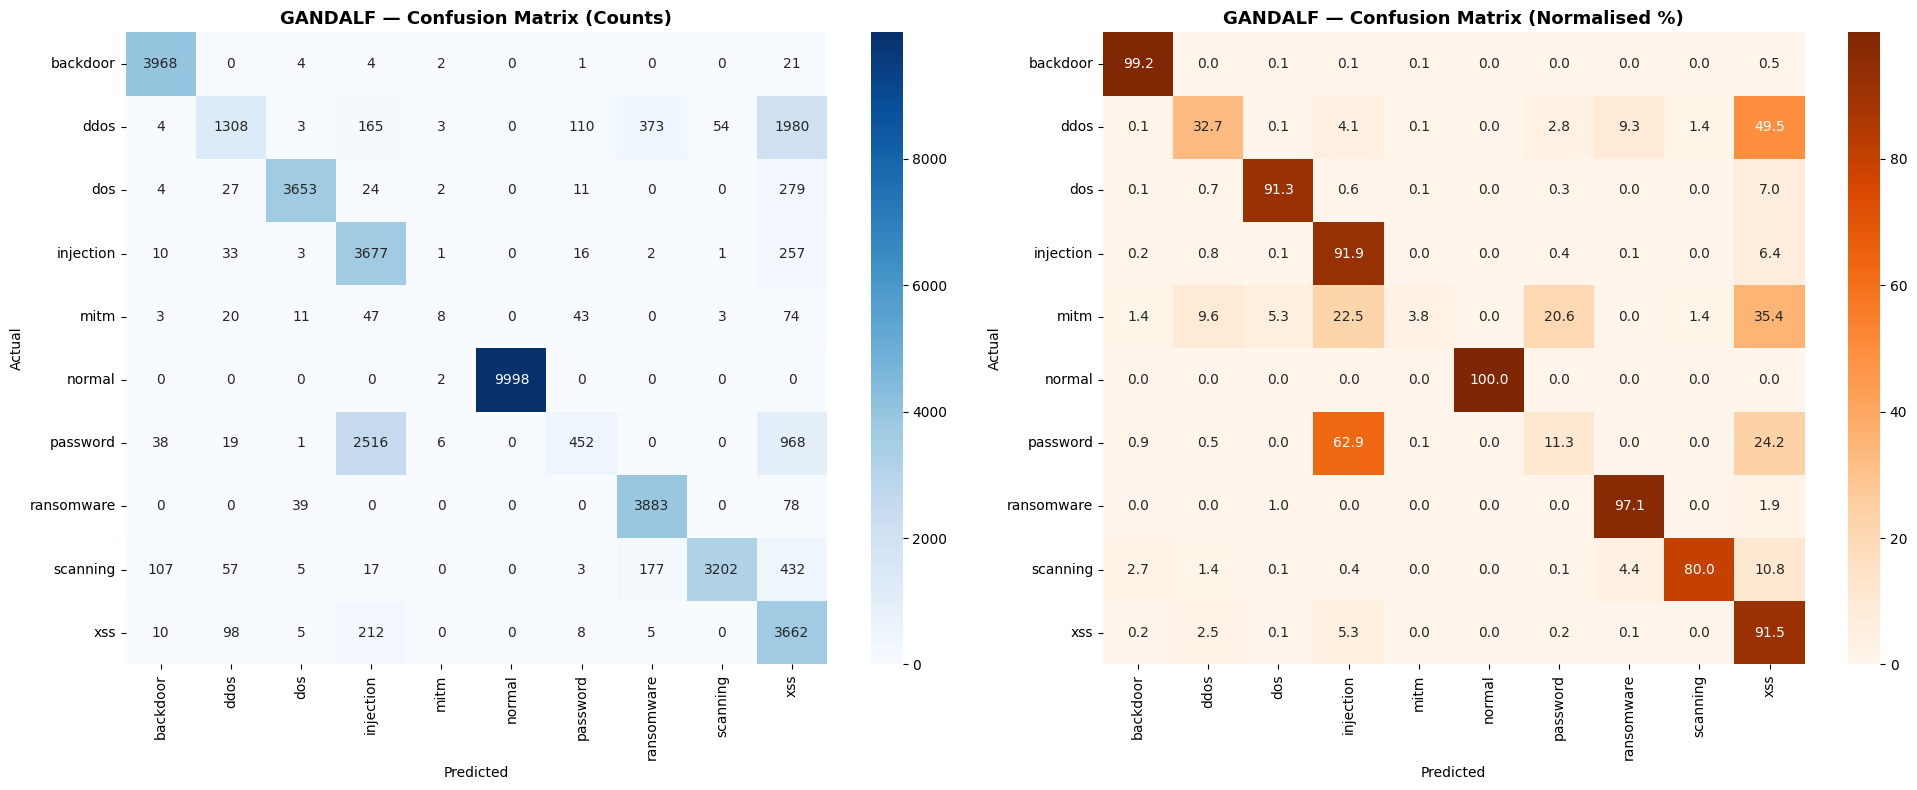


All visualisations saved to: /content/drive/MyDrive/toniot_outputs


In [9]:
# GANDALF — TABLES & VISUALISATIONS

y_true = y_test
y_pred = gandalf_preds
y_prob = gandalf_proba
label_names = list(le.classes_)


# 1. MACRO METRICS SUMMARY TABLE + BAR CHART

acc         = accuracy_score(y_true, y_pred)
prec_macro  = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec_macro   = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro    = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
mcc         = matthews_corrcoef(y_true, y_pred)
kappa       = cohen_kappa_score(y_true, y_pred)

try:
    roc_auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
except:
    roc_auc = None

macro_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (macro)", "Recall (macro)",
               "F1 (macro)", "F1 (weighted)", "MCC", "Cohen's Kappa",
               "ROC-AUC (macro)"],
    "Score": [acc, prec_macro, rec_macro, f1_macro, f1_weighted,
              mcc, kappa, roc_auc if roc_auc else float('nan')]
})
macro_df["Score"] = macro_df["Score"].round(4)

print("=" * 60)
print("  TABLE 1: GANDALF — Overall Evaluation Metrics")
print("=" * 60)
print(macro_df.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2196F3", "#FF9800", "#4CAF50", "#F44336", "#9C27B0", "#795548", "#607D8B", "#009688"]
valid = macro_df.dropna()
bars = ax.bar(valid["Metric"], valid["Score"], color=colors[:len(valid)])
for bar, val in zip(bars, valid["Score"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.15); ax.set_ylabel("Score", fontsize=12)
ax.set_title("GANDALF — Overall Evaluation Metrics", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3); plt.xticks(rotation=25, ha="right"); plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "gandalf_macro_metrics.png"), dpi=150); plt.show()


# 2. PER-CLASS PRECISION, RECALL, F1 TABLE + CHART

prec_per = precision_score(y_true, y_pred, average=None, zero_division=0)
rec_per  = recall_score(y_true, y_pred, average=None, zero_division=0)
f1_per   = f1_score(y_true, y_pred, average=None, zero_division=0)

perclass_df = pd.DataFrame({
    "Class": label_names, "Precision": np.round(prec_per, 4),
    "Recall": np.round(rec_per, 4), "F1-Score": np.round(f1_per, 4),
    "Support": [np.sum(y_true == c) for c in range(num_classes)]
})
print("=" * 60)
print("  TABLE 2: GANDALF — Per-Class Precision / Recall / F1")
print("=" * 60)
print(perclass_df.to_string(index=False)); print()

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(label_names)); w = 0.25
b1 = ax.bar(x - w, prec_per, w, label="Precision", color="#2196F3")
b2 = ax.bar(x,     rec_per,  w, label="Recall",    color="#FF9800")
b3 = ax.bar(x + w, f1_per,   w, label="F1-Score",  color="#4CAF50")
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.01: ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}", ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(label_names, rotation=45, ha="right", fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score", fontsize=12)
ax.set_title("GANDALF — Per-Class Precision / Recall / F1", fontsize=14, fontweight="bold")
ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "gandalf_perclass_prf.png"), dpi=150); plt.show()


# 3. ROC-AUC PER CLASS — TABLE + CURVES

y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
auc_per_class = []
fig, ax = plt.subplots(figsize=(12, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    class_auc = auc(fpr, tpr)
    auc_per_class.append(class_auc)
    ax.plot(fpr, tpr, label=f"{label_names[i]} (AUC={class_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate", fontsize=12); ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("GANDALF — ROC Curves (One-vs-Rest per Class)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "gandalf_roc_curves.png"), dpi=150); plt.show()

roc_df = pd.DataFrame({"Class": label_names, "ROC-AUC": np.round(auc_per_class, 4)})
print("=" * 60)
print("  TABLE 3: GANDALF — Per-Class ROC-AUC")
print("=" * 60)
print(roc_df.to_string(index=False))
if roc_auc: print(f"\n  Macro-average ROC-AUC: {roc_auc:.4f}")


# 4. MCC & COHEN'S KAPPA

def interpret_mcc(v):
    if v >= 0.9: return "Excellent"
    if v >= 0.7: return "Strong"
    if v >= 0.5: return "Moderate"
    if v >= 0.3: return "Weak"
    return "Poor"
def interpret_kappa(v):
    if v >= 0.81: return "Almost Perfect"
    if v >= 0.61: return "Substantial"
    if v >= 0.41: return "Moderate"
    if v >= 0.21: return "Fair"
    return "Slight/Poor"

print(); print("=" * 60)
print("  TABLE 4: GANDALF — MCC & Cohen's Kappa")
print("=" * 60)
print(f"  MCC          : {mcc:.4f} ({interpret_mcc(mcc)})")
print(f"  Cohen's Kappa: {kappa:.4f} ({interpret_kappa(kappa)})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, mn, val, interp, col in [
    (axes[0], "MCC", mcc, interpret_mcc(mcc), "#795548"),
    (axes[1], "Cohen's Kappa", kappa, interpret_kappa(kappa), "#607D8B")]:
    ax.barh(["Score"], [val], color=col, height=0.4)
    ax.barh(["Score"], [1.0], color="#E0E0E0", height=0.4, zorder=0)
    ax.set_xlim(0, 1.1)
    ax.text(val + 0.02, 0, f"{val:.4f} ({interp})", va="center", fontsize=12, fontweight="bold")
    ax.set_title(mn, fontsize=13, fontweight="bold"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "gandalf_mcc_kappa.png"), dpi=150); plt.show()


# 5. DUAL CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title("GANDALF — Confusion Matrix (Counts)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="Oranges", xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title("GANDALF — Confusion Matrix (Normalised %)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "gandalf_cm_dual.png"), dpi=150); plt.show()

print("\nAll visualisations saved to:", DRIVE_OUT_DIR)

In [10]:
# Overfitting / Underfitting Check


print()
print("-" * 10)
print("GANDALF")
print("-" * 10)
print(f"  Train Acc : {gandalf_train_acc:.4f}")
print(f"  Test  Acc : {gandalf_results['accuracy']:.4f}")
print(f"  Train F1  : {gandalf_train_f1:.4f}")
print(f"  Test  F1  : {gandalf_results['f1_macro']:.4f}")
print(f"  Gap       : {gandalf_train_acc - gandalf_results['accuracy']:.4f}")




----------
GANDALF
----------
  Train Acc : 0.8005
  Test  Acc : 0.8010
  Train F1  : 0.6761
  Test  F1  : 0.6769
  Gap       : -0.0005


In [11]:
# SAVE RESULTS

results_df = pd.DataFrame([{
    "model"           : "GANDALF",
    "paper"           : "Joseph & Raj 2022",
    "dataset"         : "TON-IoT Network",
    "train_samples"   : len(train_df),
    "test_samples"    : len(test_df),
    "n_features"      : n_features,
    "n_classes"       : num_classes,
    "accuracy"        : acc,
    "f1_macro"        : f1_macro,
    "f1_weighted"     : f1_weighted,
    "precision_macro" : prec_macro,
    "recall_macro"    : rec_macro,
    "mcc"             : mcc,
    "cohen_kappa"     : kappa,
    "roc_auc_macro"   : roc_auc,
    "train_acc"       : gandalf_train_acc,
    "train_f1"        : gandalf_train_f1,
}])

csv_path = os.path.join(DRIVE_OUT_DIR, "gandalf_toniot_results.csv")
results_df.to_csv(csv_path, index=False)

print("\n========== FINAL RESULTS ==========")
print(results_df.T.to_string())
print(f"\nResults saved to: {csv_path}")


========== FINAL RESULTS ==========
                                 0
model                      GANDALF
paper            Joseph & Raj 2022
dataset            TON-IoT Network
train_samples               147729
test_samples                 42209
n_features                      17
n_classes                       10
accuracy                  0.801038
f1_macro                  0.676915
f1_weighted               0.777457
precision_macro            0.76922
recall_macro              0.698933
mcc                       0.781674
cohen_kappa               0.771731
roc_auc_macro              0.97209
train_acc                 0.800547
train_f1                  0.676118

Results saved to: /content/drive/MyDrive/toniot_outputs/gandalf_toniot_results.csv
